**Hi everybody!!! This notebook is the work of a couple of weeks with nnUnet software, which was the BRATS'20 winner. I have been working with the BRATS'21 task1 data, and also competition data for brain tumour segmentation. I really expect what could be helpfull for you!**

- My first approximation was training with nnUnet data my own model, but due to kaggle GPU limits, when I was trying to train 2D, and 3D-FullRes models, I couldn't finish because it took more than 9 hours. Neverless, I used the pretrained models, and here you can see the results:

# 1.- Installing nnUNET and import libs. 

In [1]:
!git clone https://github.com/MIC-DKFZ/nnUNet.git
!git clone https://github.com/NVIDIA/apex
!pip install -e ./nnUNet
!pip install --upgrade git+https://github.com/nanohanno/hiddenlayer.git@bugfix/get_trace_graph#egg=hiddenlayer

Cloning into 'nnUNet'...
remote: Enumerating objects: 5497, done.
remote: Counting objects: 100% (1631/1631), done.
remote: Compressing objects: 100% (243/243), done.
remote: Total 5497 (delta 1500), reused 1422 (delta 1388), pack-reused 3866
Receiving objects: 100% (5497/5497), 1.34 MiB | 3.15 MiB/s, done.
Resolving deltas: 100% (4352/4352), done.
Cloning into 'apex'...
remote: Enumerating objects: 8256, done.
remote: Counting objects: 100% (343/343), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 8256 (delta 204), reused 240 (delta 139), pack-reused 7913
Receiving objects: 100% (8256/8256), 14.20 MiB | 15.30 MiB/s, done.
Resolving deltas: 100% (5605/5605), done.
Obtaining file:///kaggle/working/nnUNet
     |████████████████████████████████| 151 kB 896 kB/s 
     |████████████████████████████████| 57 kB 1.9 MB/s 
     |████████████████████████████████| 96 kB 1.9 MB/s 
  Created wheel for batchgenerators: filename=batchgenerators-0.23-py3-none-any.whl size=84784

In [2]:
###Libraries and imports
import numpy as np
import math
import random
import os
import shutil
import gzip
import shutil
import glob
import gc
import cv2 as cv
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
import tarfile
import PIL
import scipy.misc
import skimage
import nibabel as nib
import matplotlib.pyplot as plt
import sys

from PIL import Image
from tqdm import tqdm
from tensorflow import keras
from keras.models import Model, load_model
from keras.layers import Input ,BatchNormalization , Activation 
from keras.layers.convolutional import Conv2D, UpSampling2D
from keras.layers.pooling import MaxPooling2D
from keras.layers.merge import concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import optimizers 
from keras import backend as K
from sklearn.model_selection import train_test_split
from skimage.morphology import ball, disk, dilation, binary_erosion, remove_small_objects, erosion, closing, reconstruction, binary_closing
from skimage.measure import label,regionprops, perimeter
from skimage.morphology import binary_dilation, binary_opening
from skimage.filters import roberts, sobel
from skimage import measure, feature
from skimage.segmentation import clear_border
from skimage import data
from skimage.io import imread
from scipy import ndimage as ndi
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from glob import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from skimage.transform import resize
import os
import sys 
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import pydicom
from os.path import join
from fastai.vision.all import *
DEVICE = "GPU"



# 2.- Download Brats'20 pretrained model and prediction with BRATS'21 dataset

- Download pretrained Task001_BrainTumour, and setting up the nnUnet environment.

In [3]:

os.mkdir('./nnUNet_raw_data_base')
os.mkdir('./nnUNet_raw_data_base/nnUNet_raw_data')
os.mkdir('./RESULTS_FOLDER')
os.environ['nnUNet_raw_data_base'] = './nnUNet_raw_data_base/nnUNet_raw_data'
os.environ['RESULTS_FOLDER'] = './RESULTS_FOLDER'
os.environ['nnUNet_preprocessed'] = './nnUNet_preprocessed'
!nnUNet_download_pretrained_model Task001_BrainTumour



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet


######################################################
!!!!!!!!!!!!!!!!!!!!!!!!WARNING!!!!!!!!!!!!!!!!!!!!!!!
######################################################
Using the pretrained model weights is subject to the license of the dataset they were trained on. Some allow commercial use, others don't. It is your responsibility to make sure you use them appropriately! Use nnUNet_print_pretrained_model_info(task_name) to see a summary of the dataset and where to find its license!
######################################################

Download finished. Extracting...
Done


- In order to show how it work for BRATS'21, I will execute one example case.

-- Important: The data as i told you should be structurated as follow, and as you can see in brats2021dataset:
in the same study, you have to rename the files with 00000, 00001, 00002 and 00003 depending if it is an MRI type FLAIR, T1w, T1wCE of T2 respectively, and it should be in .gz format.

In [4]:
!mkdir -p ./RESULTS_FOLDER/nnUNet/2d/image_raw
!cp ../input/brats2021dataset/nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/imagesTs/BRATS_188_0000.nii ./RESULTS_FOLDER/nnUNet/2d/image_raw/BRATS_188_0000.nii.gz
!cp ../input/brats2021dataset/nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/imagesTs/BRATS_188_0001.nii ./RESULTS_FOLDER/nnUNet/2d/image_raw/BRATS_188_0001.nii.gz
!cp ../input/brats2021dataset/nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/imagesTs/BRATS_188_0002.nii ./RESULTS_FOLDER/nnUNet/2d/image_raw/BRATS_188_0002.nii.gz
!cp ../input/brats2021dataset/nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/imagesTs/BRATS_188_0003.nii ./RESULTS_FOLDER/nnUNet/2d/image_raw/BRATS_188_0003.nii.gz
!nnUNet_predict -i ./RESULTS_FOLDER/nnUNet/2d/image_raw -o ./RESULTS_FOLDER/nnUNet/2d/ -t "001" -tr nnUNetTrainerV2 -m 2d




Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

using model stored in  ./RESULTS_FOLDER/nnUNet/2d/Task001_BrainTumour/nnUNetTrainerV2__nnUNetPlansv2.1
This model expects 4 input modalities for each image
Found 1 unique case ids, here are some examples: ['BRATS_188']
If they don't look right, make sure to double check your filenames. They must end with _0000.nii.gz etc
number of cases: 1
number of cases that still need to be predicted: 1
emptying cuda cache
loading parameters for folds, None
folds is None so we will automatically look for output folders (not using 'all'!)
found the following folds:  ['./RESULTS_FOLDER/nnUNet/2d/Task001_BrainTumour/nnUNetTrainerV2__nnUNetPlansv2.

In [5]:
!ls ./RESULTS_FOLDER/nnUNet/2d/image_raw/

BRATS_188_0000.nii.gz  BRATS_188_0002.nii.gz
BRATS_188_0001.nii.gz  BRATS_188_0003.nii.gz


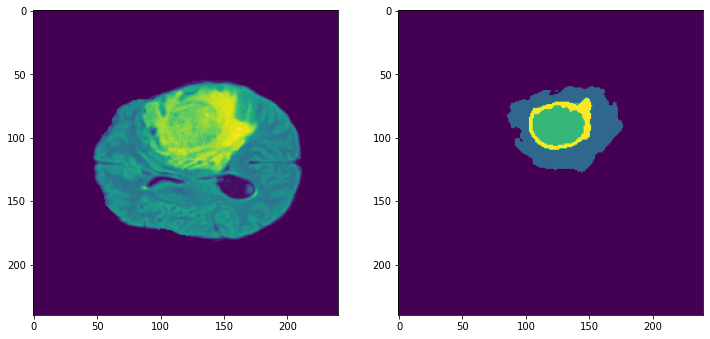

In [6]:
path_raw="../input/brats2021dataset/nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/imagesTs/BRATS_188_0000.nii"
path="./RESULTS_FOLDER/nnUNet/2d/"

plt.figure(figsize=(12,6))
plt.subplot(121)
flair_nib = nib.load(path_raw)
flair_nib_array = flair_nib.get_fdata()
plt.imshow(flair_nib_array[:,:,flair_nib_array.shape[2]//2])
plt.subplot(122)
flair_nib = nib.load(path+"BRATS_188.nii.gz")
flair_nib_array = flair_nib.get_fdata()
plt.imshow(flair_nib_array[:,:,flair_nib_array.shape[2]//2])

# 3.- Prediction of RSNA-MICCAI challenge code, transform size and format previously, and show the predictions

- Now that you can see that it works for BRAT'S 21, lets see how to manage with competition data:
-- You have to move all the data to nii.gz format, and also move to this shape configuration (240,240,155). So, the way that I have used this data, first resize to 240x240, and secondly, if there are enought .dcm images, it is no problem, I can cut in 155, and get the 240x240x155, but it is not the case, you can create empty slices.

In [7]:
!mkdir -p ./test/post/
reader = sitk.ImageSeriesReader()
reader.LoadPrivateTagsOn()
train_path="../input/rsna-miccai-brain-tumor-radiogenomic-classification/train/"
studi_id=["00000","00002","00003"]
mri_types = ["FLAIR","T1w","T1wCE","T2w"]
pixel_size_h=240
pixel_size_w=240
inner_count=0

def dicom2nifti(image_dir, out_dir, save=True):
    "given a dicom directory, loads them into single file and can save it as .nii file"
    reader = sitk.ImageSeriesReader()
    reader.LoadPrivateTagsOn()
    filenamesDICOM = reader.GetGDCMSeriesFileNames(str(image_dir))
    reader.SetFileNames(filenamesDICOM)
    img = reader.Execute()
    img = sitk.Cast(img, sitk.sitkFloat32)
    
    if save:
        sitk.WriteImage(img, f'{out_dir}/{image_dir.parent.name}.nii')
    else:
        return img

def resample_nifti(image_dir, ref_image, fn, save=True):
    "resample using a reference image"

    image = sitk.ReadImage(str(image_dir), sitk.sitkFloat32)
    
    initial_transform = sitk.CenteredTransformInitializer(ref_image, 
                                                          image, 
                                                          sitk.Euler3DTransform(), 
                                                          sitk.CenteredTransformInitializerFilter.GEOMETRY)

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(ref_image)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetTransform(initial_transform)
    resampler.SetOutputSpacing(ref_image.GetSpacing())
    resampler.SetSize((ref_image.GetSize()))
    resampler.SetOutputDirection(ref_image.GetDirection())
    resampler.SetOutputOrigin(ref_image.GetOrigin())
    resampler.SetDefaultPixelValue(image.GetPixelIDValue())
    resamped_image = resampler.Execute(image)
    
    if save:
        sitk.WriteImage(resamped_image, fn)

    return resamped_image

ref_image = sitk.ReadImage('../input/sri24-dataset/sri24/spgr.nii', sitk.sitkFloat32)
!mkdir -p ./tmp/T1w
!mkdir -p ./tmp/T1wCE
!mkdir -p ./tmp/T2w
!mkdir -p ./tmp/FLAIR

for c in tqdm(studi_id):
    path=join(train_path,c)
    samples = [Path("../input/rsna-miccai-brain-tumor-radiogenomic-classification/train/"+c)]
    path_train_t2w, path_train_t1wce,path_train_t1w,path_train_flair = [],[],[],[]
    for each in samples:
        path_train_t2w.append(each.ls()[0])
        path_train_t1wce.append(each.ls()[1])
        path_train_t1w.append(each.ls()[2])
        path_train_flair.append(each.ls()[3])
    for fn in path_train_t1w: dicom2nifti(fn, "./tmp/T1w/")
    for fn in path_train_t1wce: dicom2nifti(fn, "./tmp/T1wCE/")
    for fn in path_train_t1w: dicom2nifti(fn, "./tmp/T2w/")
    for fn in path_train_flair: dicom2nifti(fn, "./tmp/FLAIR/")      
    for b in tqdm(mri_types):
        path=join(train_path,c)
        file=[]
        for each in  [Path(join('./tmp/',b))]:
            file.append(each.ls()[0])        
        for fn2 in file:
            pat_id = str(fn2).split('/')[-1].split('.')[0]
            if b=="FLAIR":
                final_fn = f"./test/post/"+pat_id+"_0000.nii.gz"
            if b=="T1w":
                final_fn = f"./test/post/"+pat_id+"_0001.nii.gz"
            if b=="T1wCE":
                final_fn = f"./test/post/"+pat_id+"_0002.nii.gz"    
            if b=="T2w":
                final_fn = f"./test/post/"+pat_id+"_0003.nii.gz"
            resample_nifti(fn2, ref_image, final_fn, True)
            os.remove(str(fn2))

100%|██████████| 3/3 [00:30<00:00, 10.10s/it]


In [8]:
!ls ./test/post/

00000_0000.nii.gz  00000_0003.nii.gz  00002_0002.nii.gz  00003_0001.nii.gz
00000_0001.nii.gz  00002_0000.nii.gz  00002_0003.nii.gz  00003_0002.nii.gz
00000_0002.nii.gz  00002_0001.nii.gz  00003_0000.nii.gz  00003_0003.nii.gz


- I do the predictions for 2d and 3d_fullres, and show the result, that it is not so good, and this is the main problem, I don't know if this is registration problem, or other kind of problem.

In [9]:
!nnUNet_predict -i ./test/post/ -o ./RESULTS_FOLDER/nnUNet/2d/ -t 001 -tr nnUNetTrainerV2 -m 3d_fullres --disable_tta 



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

using model stored in  ./RESULTS_FOLDER/nnUNet/3d_fullres/Task001_BrainTumour/nnUNetTrainerV2__nnUNetPlansv2.1
This model expects 4 input modalities for each image
Found 3 unique case ids, here are some examples: ['00003' '00003' '00002']
If they don't look right, make sure to double check your filenames. They must end with _0000.nii.gz etc
number of cases: 3
number of cases that still need to be predicted: 3
emptying cuda cache
loading parameters for folds, None
folds is None so we will automatically look for output folders (not using 'all'!)
found the following folds:  ['./RESULTS_FOLDER/nnUNet/3d_fullres/Task001_BrainTumour/nnU

In [10]:
!ls ./RESULTS_FOLDER/nnUNet/2d/

00000.nii.gz  00003.nii.gz	Task001_BrainTumour  plans.pkl
00002.nii.gz  BRATS_188.nii.gz	image_raw	     postprocessing.json


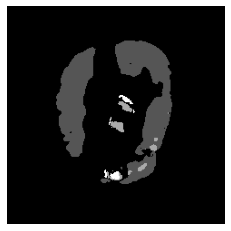

In [11]:
def get_array(fn):
    "opens .nii file and return the array"
    img = sitk.ReadImage(str(fn))
    imgd = sitk.GetArrayFromImage(img)
    return imgd

def plot_slice(imgd, sli):
    "given an image of shape slices x height x width, plots a slice"
    plt.imshow(imgd[sli], cmap='gray')
    plt.axis('off')
    
def get_array_plot(fn, sli):
    imgd = get_array(fn)
    plot_slice(imgd, sli)

get_array_plot(f'./RESULTS_FOLDER/nnUNet/2d/00003.nii.gz', 105)

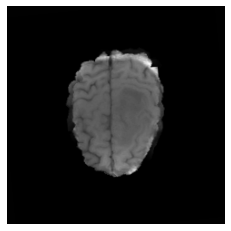

In [12]:
get_array_plot(f'./test/post/00003_0003.nii.gz', 125)

In [13]:
!nnUNet_predict -i ./test/post/ -o ./RESULTS_FOLDER/nnUNet/2d/ -t "001" -tr nnUNetTrainerV2 -m 2d



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

using model stored in  ./RESULTS_FOLDER/nnUNet/2d/Task001_BrainTumour/nnUNetTrainerV2__nnUNetPlansv2.1
This model expects 4 input modalities for each image
Found 3 unique case ids, here are some examples: ['00003' '00003' '00002']
If they don't look right, make sure to double check your filenames. They must end with _0000.nii.gz etc
number of cases: 3
number of cases that still need to be predicted: 0
emptying cuda cache
loading parameters for folds, None
folds is None so we will automatically look for output folders (not using 'all'!)
found the following folds:  ['./RESULTS_FOLDER/nnUNet/2d/Task001_BrainTumour/nnUNetTrainerV2__nn

# 4.- How to train your own model with BRATs'21 dataset

- **If you have interest and home machines in order to train the Brats'21 model, you can use the next code in order to create the specific configurations with nnUnet (https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/dataset_conversion.md):**

I did for you and I share my dataset with you, please if it is hepfull upvote: https://www.kaggle.com/victorfernandezalbor/brats2021dataset

In [14]:
path_raw_brain="../input/brats2021dataset/nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/"
path_tr="imagesTr/"
path_ts="imagesTs/"
path_lbr="labelsTr/"
path_lbs="labelsTs/"
path_raw_brain="nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/"
task="Task101_BrainTumour"

#Uncomment and try the next code by yourself......

#!ln -rs ../input/brats2021dataset/nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/* ./nnUNet_raw_data_base/nnUNet_raw_data/Task101_BrainTumour/

##The next code generate one json which the nnUnet software use for know the test and train data, in my own dataset 
##I've added the propper one, so maybe it is not usefull for you, but it is necessary.
## Please feel free if you miss something to ask me.

#sys.path.insert(1,'../input/generatejsonbrats/')
#sys.path.insert(1,'../input/nnunet-batchgenerators/batchgenerators/')
#from batchgenerators.utilities.file_and_folder_operations import *
#from batchgenerators import *
#import file_and_folder_operations
#from utils import generate_dataset_json
#generate_dataset_json(join(path_raw_brain,'dataset.json'), path_raw_brain+path_tr, path_raw_brain+path_ts, ("flair", "t1", "t1ce", "t2"),
#                    labels={"0": "background", "1": "necrotic tumor core","2": "peritumoral edematous/invaded tissue","3":"", "4": "GD-enhancing tumor"} ,dataset_name=task, license='hands off!')


- Uncoment the next lines for running, first the preprocess, which make some augmentation and proper preprocessing in the images, and then for training the 2d and 3d_fullres configuration, with 4 folds.

More info, in the web page of the project: https://github.com/MIC-DKFZ/nnUNet#model-training

In [15]:
#!nnUNet_plan_and_preprocess -t 101 -tf 1 --verify_dataset_integrity

In [16]:
#!nnUNet_train 2d nnUNetTrainerV2 101 4 --npz

In [17]:
#nnUNet_train 3d_fullres nnUNetTrainerV2 TaskXXX_MYTASK FOLD --npz
#!nnUNet_train 3d_fullres nnUNetTrainerV2 101 4 --npz